# IRAS 07546+3928 full-spectrum fitting with Nautilus

This notebook follows the dynesty example and fits the 4200–6800 Å rest-frame spectrum with the same full additive GalSpec model. It deliberately excludes the multiplicative polynomial and masks 5770–6000 Å. Nautilus uses an HDF5 checkpoint, so an interrupted fit can resume.

In [10]:
import os
import sys
from pathlib import Path

os.environ.setdefault('OMP_NUM_THREADS', '1')

import matplotlib.pyplot as plt
import numpy as np
from astropy.modeling import fitting
import galspec

repo_root = Path(galspec.__file__).resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from develop.dev_dynesty.demo_ir07546_full_spectrum import (
    build_model, load_spectrum, local_bounds)
from develop.dev_nautilus.demo_ir07546_nautilus import install_serializable_ties

N_PROCESSES = 6
N_LIVE = 400
N_EFF = 3000
RANDOM_SEED = 20260901
checkpoint = repo_root / 'example/iras07546_nautilus_checkpoint.hdf5'

%matplotlib inline

## Prepare the spectrum and model

The deterministic fit supplies a sensible starting region for finite nested-sampling priors. The likelihood uses only unmasked pixels.

In [2]:
wave_all, flux_all, error_all, fit_mask = load_spectrum()
model_initial = install_serializable_ties(build_model())

model_levmar = fitting.LevMarLSQFitter()(
    model_initial, wave_all, flux_all,
    weights=fit_mask.astype(float), maxiter=10000)

wave = wave_all[fit_mask]
flux = flux_all[fit_mask]
error = error_all[fit_mask]
bounds = local_bounds(model_levmar)

print(f'{wave.size:,} fitted pixels')
print(f'{len(bounds)} free parameters')
print('No multiplicative polynomial:', 'multi' not in model_levmar.submodel_names)

51,918 fitted pixels
39 free parameters
No multiplicative polynomial: True


## Run Nautilus

`progress=True` displays the Nautilus status table. Six processes evaluate likelihood batches in parallel. Rerunning this cell resumes from the checkpoint; delete the checkpoint or set `resume=False` for a completely fresh run. No likelihood-call ceiling is applied, so the run targets `N_EFF=3000`.

In [3]:
nautilus_fit = galspec.Nautilus_Fit(
    model_levmar, wave, flux, error,
    bounds_dict=bounds,
    n_live=N_LIVE,
    n_processes=N_PROCESSES,
    seed=RANDOM_SEED,
    filepath=checkpoint,
    resume=True,
)

samples, _, parameter_names = nautilus_fit.fit(
    progress=True, n_eff=N_EFF)
model_best, _, theta_best = nautilus_fit.get_best_fit()

print(f'Runtime: {nautilus_fit.runtime_seconds / 60:.2f} min')
print(f'Likelihood calls: {nautilus_fit.ncall:,}')
print(f'log Z: {nautilus_fit.log_evidence:.3f}')
print(f'Equal-weight posterior samples: {len(samples):,}')

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 175    | 1        | 4        | 401268   | N/A    | 16962 | +117507.1
Runtime: 15.93 min
Likelihood calls: 401,268
log Z: 117507.155
Equal-weight posterior samples: 2,241


## Inspect the fitted spectrum

In [9]:
model_flux_all = model_best(wave_all)
residual_all = (flux_all - model_flux_all) / error_all
residual = (flux - model_best(wave)) / error
reduced_chi2 = np.sum(residual**2) / (wave.size - nautilus_fit.ndim)

fig, (axis, residual_axis) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]})
axis.step(wave_all, flux_all, where='mid', color='0.35', lw=0.45, label='Data')
axis.plot(wave_all, model_flux_all, color='tab:red', lw=1, label='Nautilus best fit')
axis.axvspan(5770, 6000, color='0.85', label='Excluded')
axis.set_ylabel('Scaled flux')
axis.legend()
residual_axis.plot(wave_all, residual_all, color='0.35', lw=0.4)
residual_axis.axhline(0, color='tab:red', lw=0.8)
residual_axis.axvspan(5770, 6000, color='0.85')
residual_axis.set(xlabel='Rest wavelength (Å)', ylabel='Residual / σ', ylim=(-8, 8))
fig.suptitle(f'IRAS 07546+3928: reduced χ² = {reduced_chi2:.2f}')
fig.tight_layout()
plt.show()

/var/folders/x7/ww3bm0kx1mq7v6r3dk8mccw80000gn/T/ipykernel_65406/2393121242.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Posterior summaries and plots

A full 39-dimensional corner plot is unwieldy, so this example selects six representative parameters. Replace `selected_parameters` with any names printed below.

In [5]:
q16, q50, q84 = nautilus_fit.get_quantiles()
for name, median, lower, upper in zip(parameter_names, q50, q16, q84):
    print(f'{name:24s} {median:12.5g}  -{median-lower:.3g}  +{upper-median:.3g}')

amplitude_0                   0.54813  -0.000265  +0.000268
alpha_0                        1.1037  -0.00394  +0.00396
amplitude_1                   0.22372  -0.00168  +0.00169
stddev_1                       1183.7  -21.2  +21.9
z_1                        1.5497e-05  -1.15e-05  +2.71e-05
amp_c_2                        2.1449  -0.00828  +0.00843
dv_c_2                         253.97  -2.02  +1.94
sigma_c_2                      1089.1  -2.69  +2.7
amp_w0_2                      0.10859  -0.000666  +0.00068
dv_w0_2                       -380.31  -14.8  +14.5
sigma_w0_2                     4069.8  -8.66  +3.53
amplitude_3                     1.652  -0.0185  +0.0183
amp_c_4                        0.7273  -0.00721  +0.00692
dv_c_4                         87.872  -5.18  +5.12
sigma_c_4                      939.68  -10.5  +10.6
amp_w0_4                      0.27544  -0.00965  +0.00994
dv_w0_4                       -270.88  -30  +29.1
sigma_w0_4                     2983.1  -60.5  +60.5
amplitude_

Corner parameters: ['amplitude_0', 'alpha_0', 'dv_c_2', 'sigma_c_2']


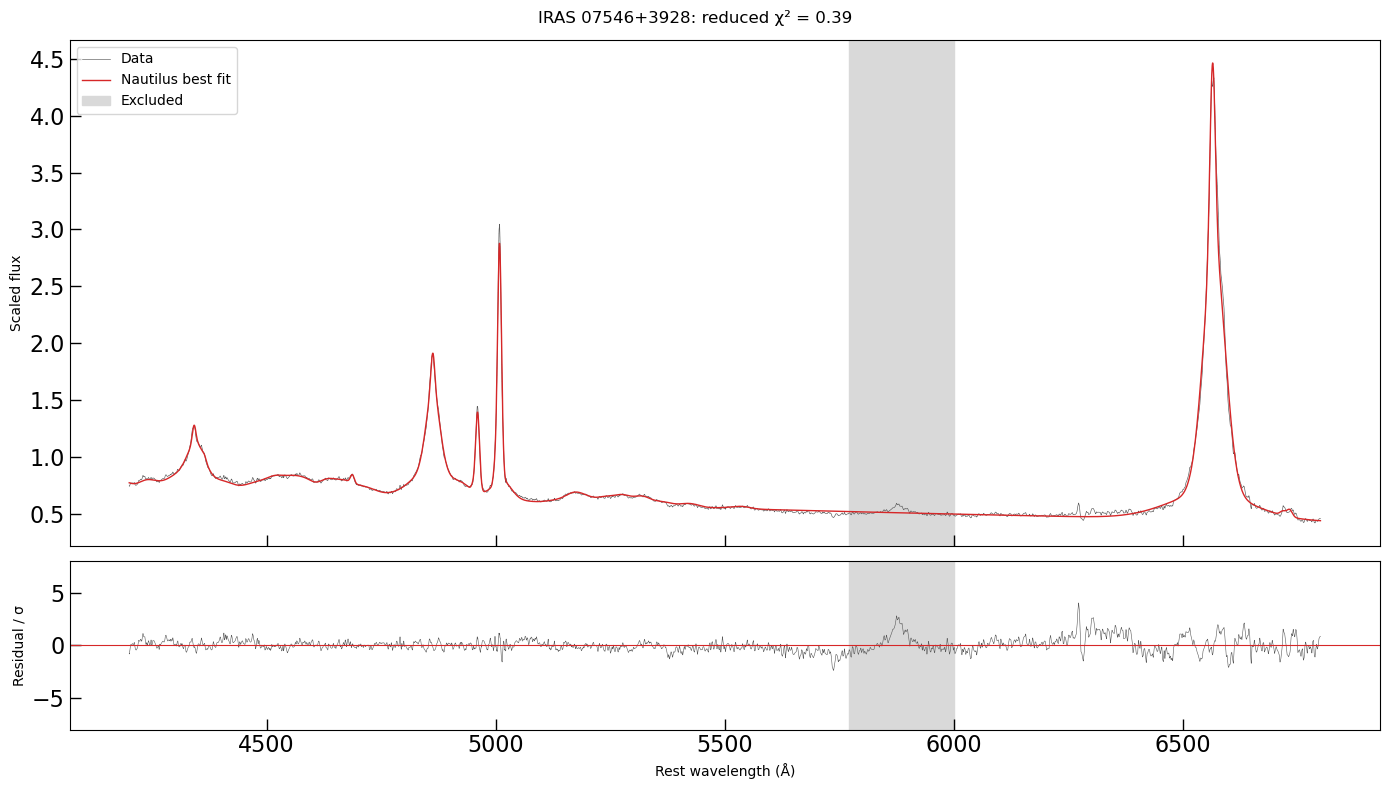

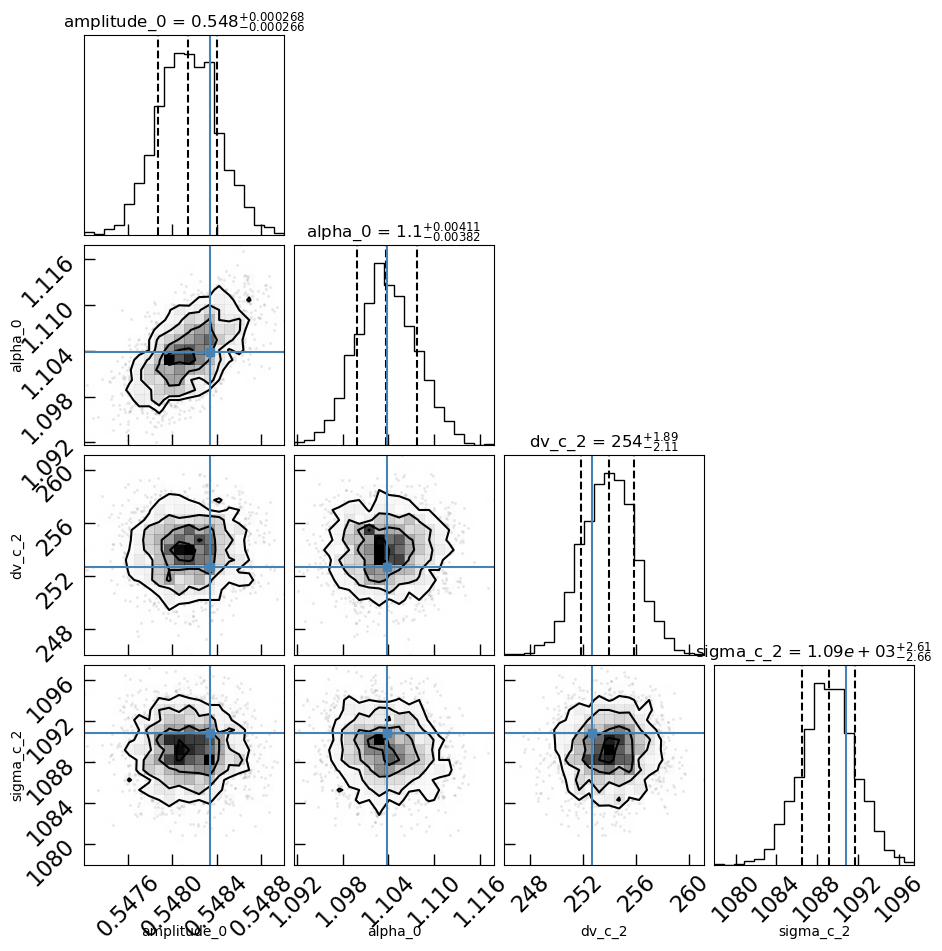

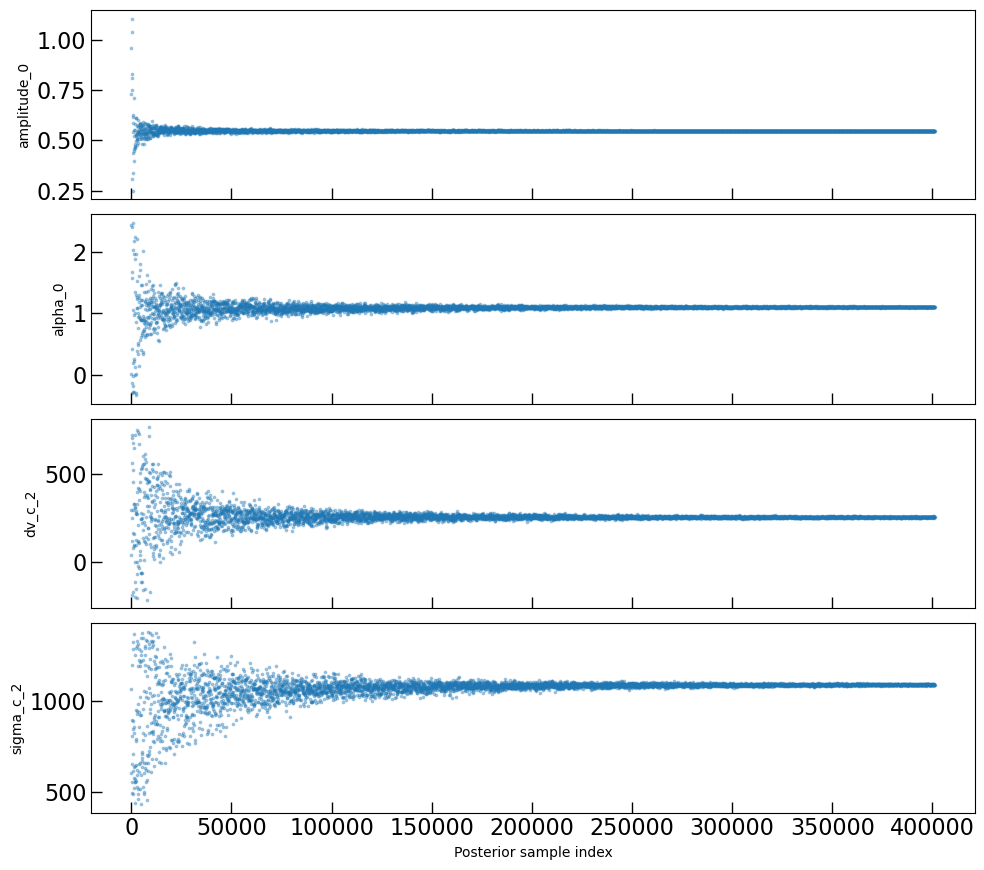

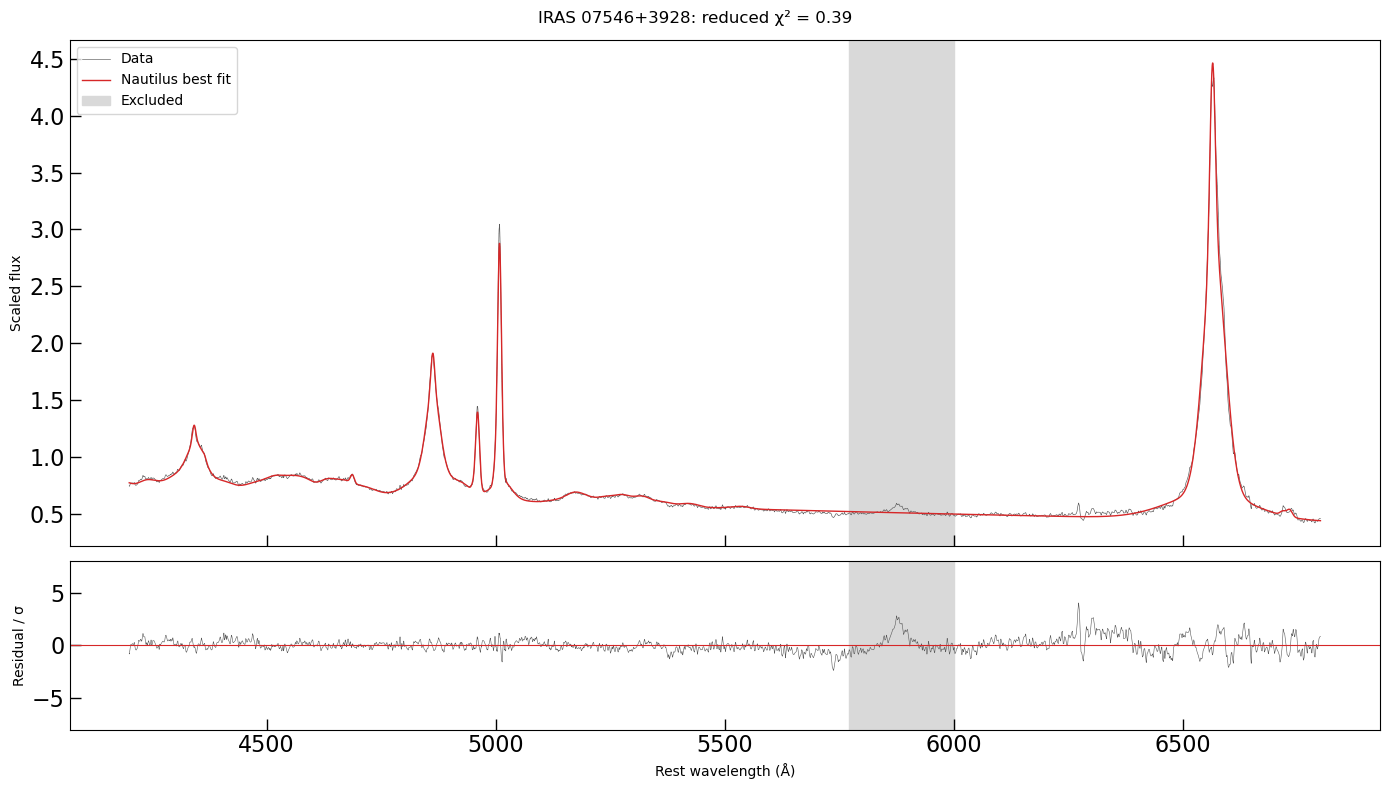

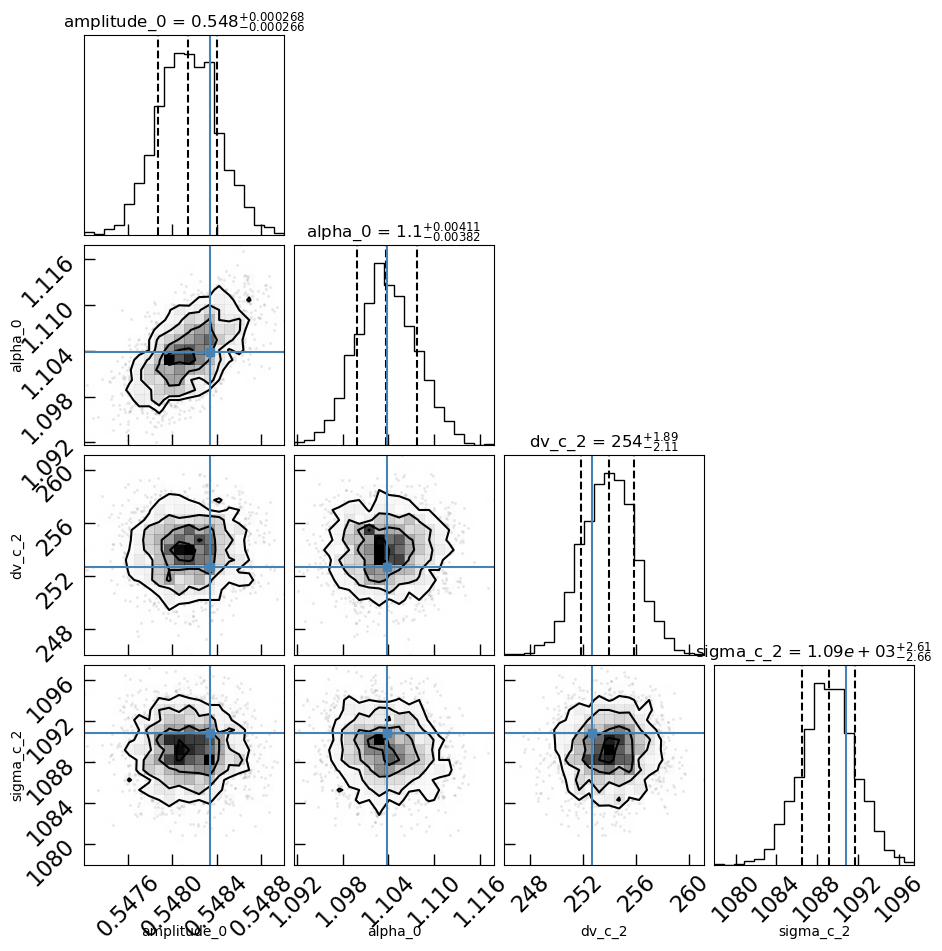

In [11]:
selected_parameters = [
    name for name in parameter_names
    if any(token in name for token in ('alpha', 'amplitude_0', 'sigma_c_2', 'dv_c_2'))
][:6]
print('Corner parameters:', selected_parameters)
corner_figure = nautilus_fit.plot_corner(
    parameters=selected_parameters, show_titles=True,
    quantiles=[0.16, 0.5, 0.84], title_fmt='.3g')
plt.show()

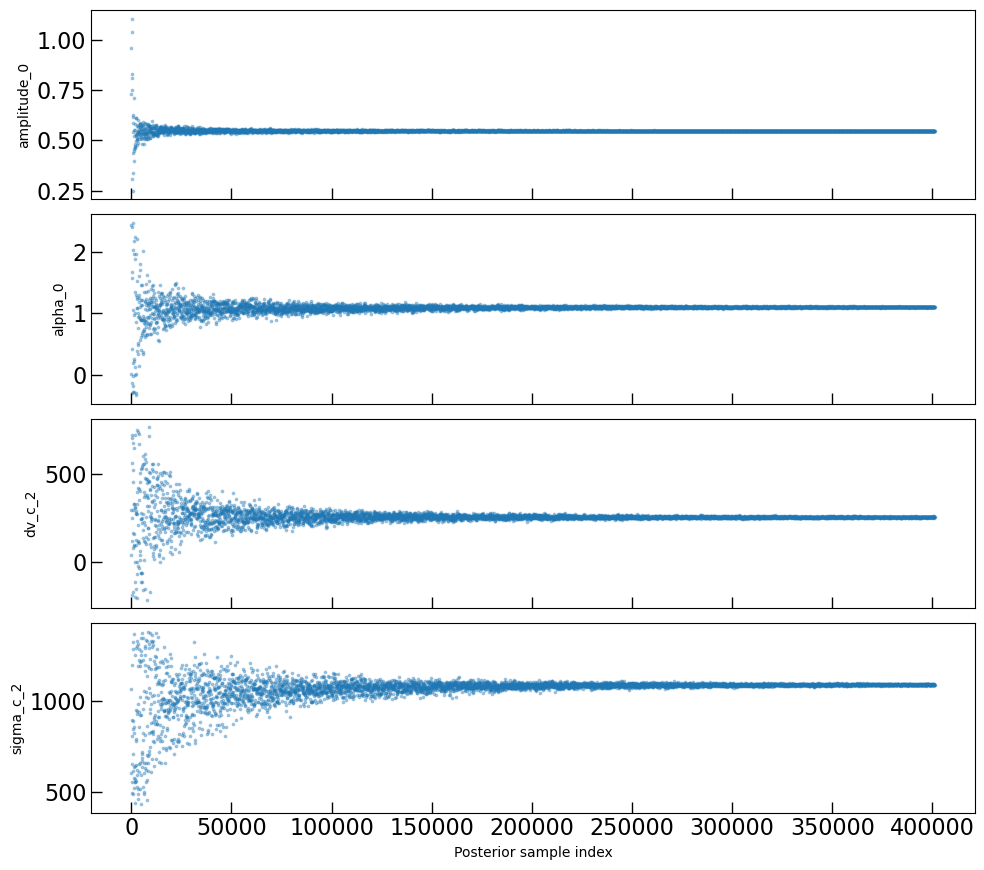

In [12]:
trace_figure, _ = nautilus_fit.plot_trace(parameters=selected_parameters)
plt.show()

## Save and reload the complete fit

In [13]:
output_file = repo_root / 'example/iras07546_nautilus_fit.fits'
galspec.save_nautilus_fit_to_fits(nautilus_fit, output_file)
loaded_fit = galspec.load_nautilus_fit_from_fits(output_file)
print(f'Saved and reloaded {loaded_fit.samples.shape[0]:,} weighted samples')

Saved and reloaded 401,174 weighted samples
